Partie 1 – Exploration du corpus
1) Charger les données CSV ;

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re

df = pd.read_csv("../data/smart_reviews_raw.csv")

2) Combien d'avis contient le dataset ?

In [7]:
df.shape[0]

1200

3) Combien de colonnes possède-t-il ?

In [4]:
df.shape[1]

8

4) Quel est le type de chaque colonne ?

In [6]:
df.dtypes

id_avis      object
date         object
source       object
produit      object
texte        object
sentiment    object
note          int64
langue       object
dtype: object

5) Existe-t-il des valeurs manquantes ?

In [9]:
df.isnull().sum()

id_avis      0
date         0
source       0
produit      0
texte        5
sentiment    0
note         0
langue       0
dtype: int64

6) Identifier quelques types de texte en affichant par exemple : texte normal ; texte vide ; texte
contenant une URL ; texte contenant une mention ; texte contenant un hashtag ; texte
contenant des emojis ; texte avec beaucoup de ponctuation ; texte en majuscules ; texte avec
répétition de caractères.

Texte normal

In [18]:
import re

textes = df["texte"].astype(str)

print("Exemples de textes normaux :")

compteur = 0

for texte in textes:
    if (
        texte.strip()
        and not re.search(r"https?://|www\.", texte)
        and not re.search(r"@\w+", texte)
        and not re.search(r"#\w+", texte)
    ):
        print("-", texte)
        compteur += 1
        
        if compteur == 5:
            break

Exemples de textes normaux :
- Très  bonne  expérience,  simple  et  efficace.
- Produit  parfait,  rien  à  signaler.
- Produit excellent, je suis très satisfait. !!!
- LA BATTERIE TIENT VRAIMENT BIEN ET L'ÉCRAN EST SUPERBE.
- Très satisfait de mon achat 👍 😊


Texte vide

In [21]:
textes_vides = df[df["texte"].fillna("").astype(str).str.strip() == ""]

print("Nombre de textes vides :", len(textes_vides))

textes_vides.head(8)

Nombre de textes vides : 6


,id_avis,date,source,produit,texte,sentiment,note,langue
46,AV0047,2026-02-24,réseaux_sociaux,SmartWatch Pro,NaN,positif,4,fr
108,AV0109,2026-01-24,email,SmartPhone Y,NaN,positif,5,fr
310,AV0311,2026-02-13,réseaux_sociaux,Ordinateur NovaBook,NaN,positif,5,fr
640,AV0641,2026-08-25,réseaux_sociaux,SmartPhone Y,NaN,positif,5,fr
781,AV0782,2026-05-21,email,SmartPhone Y,NaN,neutre,4,fr
951,AV0952,2026-06-11,web,Ordinateur NovaBook,,positif,4,fr


Texte contenant une URL

In [22]:
mask_url = textes.str.contains(
    r"https?://|www\.",
    case=False,
    regex=True
)

textes_url = df[mask_url]

print("Nombre de textes contenant une URL :", len(textes_url))

textes_url[["texte"]].head()

Nombre de textes contenant une URL : 143


,texte
16,"Produit parfait, rien à signaler. https://exam..."
30,"Très bonne expérience, simple et efficace. htt..."
31,"Je viens de recevoir le produit, à voir dans l..."
34,"Produit parfait, rien à signaler. https://exam..."
35,"Très bon produit, la qualité est au rendez-vou..."


Texte contenant une mention

In [23]:
mask_mention = textes.str.contains(
    r"@\w+",
    regex=True
)

textes_mentions = df[mask_mention]

print("Nombre de textes contenant une mention :", len(textes_mentions))

textes_mentions[["texte"]].head()

Nombre de textes contenant une mention : 128


,texte
9,@client Livraison rapide et produit conforme à...
32,@client Service client réactif et commande reç...
40,@client La qualité est correcte sans être exce...
44,"@client Je recommande vivement, tout fonctionn..."
45,@client Excellent rapport qualité-prix.


Texte contenant un hashtag

In [24]:
mask_hashtag = textes.str.contains(
    r"#\w+",
    regex=True
)

textes_hashtags = df[mask_hashtag]

print("Nombre de textes contenant un hashtag :", len(textes_hashtags))

textes_hashtags[["texte"]].head()

Nombre de textes contenant un hashtag : 127


,texte
1,Très satisfait de mon achat 👍 #avis
12,La batterie tient vraiment bien et l'écran est...
15,Produit correct pour son prix. #avis
38,"Très bonne expérience, simple et efficace. #avis"
69,La batterie tient vraiment bien et l'écran est...


Textes contenant des emojis

In [25]:
# Création d'une expression régulière permettant de détecter les emojis
emoji_pattern = re.compile(

    # Début de la liste des caractères recherchés
    "["
    
    # Emojis et symboles divers
    "\U0001F300-\U0001F5FF"
    
    # Émoticônes et visages
    "\U0001F600-\U0001F64F"
    
    # Moyens de transport et symboles
    "\U0001F680-\U0001F6FF"
    
    # Symboles supplémentaires
    "\U0001F700-\U0001F77F"
    
    # Symboles supplémentaires
    "\U0001F780-\U0001F7FF"
    
    # Symboles supplémentaires
    "\U0001F800-\U0001F8FF"
    
    # Emojis récents et symboles
    "\U0001F900-\U0001F9FF"
    
    # Emojis et symboles récents
    "\U0001FA00-\U0001FAFF"
    
    # Symboles divers comme ⭐, ✨, ❤️, etc.
    "\U00002700-\U000027BF"
    
    # Fin de la liste des caractères recherchés
    "]+",

    # Permet de gérer correctement les caractères Unicode, notamment les emojis
    flags=re.UNICODE
)

# Parcourt chaque texte et vérifie s'il contient au moins un emoji
# bool(...) transforme le résultat en True (emoji trouvé) ou False (aucun emoji)
mask_emoji = textes.apply(lambda x: bool(emoji_pattern.search(x)))

# Sélectionne uniquement les lignes du DataFrame correspondant
# aux textes qui contiennent au moins un emoji
textes_emojis = df[mask_emoji]

# Affiche le nombre de textes contenant des emojis
print("Nombre de textes contenant des emojis :", len(textes_emojis))

# Affiche les 5 premiers textes contenant des emojis
textes_emojis[["texte"]].head()

Nombre de textes contenant des emojis : 192


,texte
1,Très satisfait de mon achat 👍 #avis
5,Très satisfait de mon achat 👍 😊
7,Très satisfait de mon achat 👍
10,Très satisfait de mon achat 👍 !!!
19,"Je viens de recevoir le produit, à voir dans l..."


Textes avec beaucoup de ponctuation

In [26]:
import string

def nombre_ponctuation(texte):
    return sum(1 for caractere in texte if caractere in string.punctuation)

ponctuation = textes.apply(nombre_ponctuation)

print("Exemples de textes avec beaucoup de ponctuation :")

df.loc[ponctuation >= 5, ["texte"]].head()

Exemples de textes avec beaucoup de ponctuation :


,texte
3,"Produit excellent, je suis très satisfait. !!!"
16,"Produit parfait, rien à signaler. https://exam..."
25,"Produit reçu endommagé, je suis mécontent. !!!"
30,"Très bonne expérience, simple et efficace. htt..."
31,"Je viens de recevoir le produit, à voir dans l..."


Textes en majuscules

In [27]:
def est_majuscules(texte):
    lettres = [c for c in texte if c.isalpha()]
    
    if len(lettres) == 0:
        return False
    
    return sum(c.isupper() for c in lettres) / len(lettres) >= 0.8

mask_majuscules = textes.apply(est_majuscules)

textes_majuscules = df[mask_majuscules]

print("Nombre de textes en majuscules :", len(textes_majuscules))

textes_majuscules[["texte"]].head()

Nombre de textes en majuscules : 146


,texte
4,LA BATTERIE TIENT VRAIMENT BIEN ET L'ÉCRAN EST...
6,SERVICE CLIENT RÉACTIF ET COMMANDE REÇUE RAPID...
17,SERVICE CLIENT RÉACTIF ET COMMANDE REÇUE RAPID...
23,"PRODUIT EXCELLENT, JE SUIS TRÈS SATISFAIT."
24,TRÈS SATISFAIT DE MON ACHAT 👍


Textes avec répétition de caractères

In [30]:
mask_repetition = textes.str.contains(
    r"(.)\1{2,}",
    regex=True
)

textes_repetition = df[mask_repetition]

print(
    "Nombre de textes avec répétition de caractères :",
    len(textes_repetition)
)

textes_repetition[["texte"]].head(5)

Nombre de textes avec répétition de caractères : 165


C:\Users\UNiK\AppData\Local\Temp\ipykernel_5264\1974043422.py:1: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  mask_repetition = textes.str.contains(


,texte
3,"Produit excellent, je suis très satisfait. !!!"
10,Très satisfait de mon achat 👍 !!!
14,Qualité décevante pour ce prix. !!!
25,"Produit reçu endommagé, je suis mécontent. !!!"
28,"Produit excellent, je suis trèèès satisfait."


7) Mesurer la longueur des textes en créant une nouvelle colonne « longueur » pour déterminer :
longueur minimale ; longueur maximale ; longueur moyenne ; médiane et quartiles.

Mesurer la longueur des textes

In [32]:
df["longueur"] = df["texte"].fillna("").astype(str).str.len()
df[["texte", "longueur"]].head()

,texte,longueur
0,"Très bonne expérience, simple et efficace.",47
1,Très satisfait de mon achat 👍 #avis,35
2,"Produit parfait, rien à signaler.",37
3,"Produit excellent, je suis très satisfait. !!!",46
4,LA BATTERIE TIENT VRAIMENT BIEN ET L'ÉCRAN EST...,55


Longueur minimale

In [34]:
longueur_min = df["longueur"].min()

print("Longueur minimale :", longueur_min)

Longueur minimale : 0


Longueur maximale

In [35]:
longueur_max = df["longueur"].max()

print("Longueur maximale :", longueur_max)

Longueur maximale : 636


Longueur moyenne

In [36]:
longueur_moyenne = df["longueur"].mean()

print("Longueur moyenne :", longueur_moyenne)

Longueur moyenne : 48.96333333333333


determiner la Médiane

In [37]:
mediane = df["longueur"].median()

print("Médiane :", mediane)

Médiane : 48.0


Quartiles

In [38]:
quartiles = df["longueur"].quantile([0.25, 0.50, 0.75])

print(quartiles)

0.25    37.0
0.50    48.0
0.75    56.0
Name: longueur, dtype: float64


8) Visualiser la distribution de la longueur des avis puis répondre aux questions

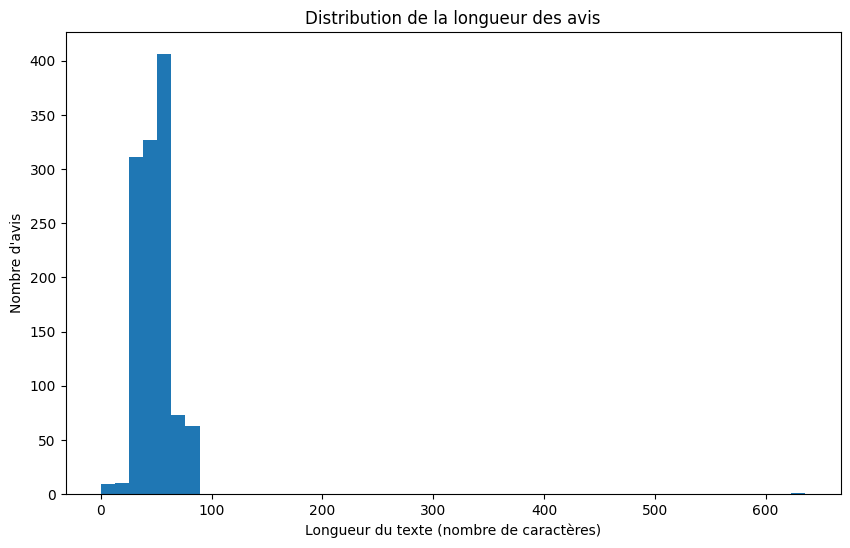

In [39]:
plt.figure(figsize=(10, 6))

plt.hist(df["longueur"], bins=50)

plt.title("Distribution de la longueur des avis")
plt.xlabel("Longueur du texte (nombre de caractères)")
plt.ylabel("Nombre d'avis")

plt.show()

a) Existe-t-il des textes anormalement longs ?

In [40]:
Q1 = df["longueur"].quantile(0.25)
Q3 = df["longueur"].quantile(0.75)

IQR = Q3 - Q1

seuil_long = Q3 + 1.5 * IQR

print("Q1 :", Q1)
print("Q3 :", Q3)
print("IQR :", IQR)
print("Seuil des textes anormalement longs :", seuil_long)

Q1 : 37.0
Q3 : 56.0
IQR : 19.0
Seuil des textes anormalement longs : 84.5


In [43]:
textes_tres_longs = df[df["longueur"] > seuil_long]

print(
    "Nombre de textes anormalement longs :",
    len(textes_tres_longs)
)

Nombre de textes anormalement longs : 41


In [42]:
textes_tres_longs[["texte", "longueur"]].head(10)

,texte,longueur
31,"Je viens de recevoir le produit, à voir dans l...",86
51,"Je viens de recevoir le produit, à voir dans l...",86
110,La batterie tient vraiment bien et l'écran est...,88
123,Service client réactif et commande reçue rapid...,85
145,Livraison rapide et produit conforme à mes att...,85
294,"Je recommande vivement, tout fonctionne parfai...",86
306,"Je viens de recevoir le produit, à voir dans l...",87
313,"Je viens de recevoir le produit, à voir dans l...",87
318,La batterie tient vraiment bien et l'écran est...,88
340,"Je viens de recevoir le produit, à voir dans l...",87


In [44]:
df.shape[0]

1200

Le dataset contient 1 200 avis, dont 41 sont identifiés comme anormalement longs selon la méthode de l’IQR. Cela représente environ 3,42 % des observations. Ces textes sont donc minoritaires dans le corpus, mais ils devront être examinés afin de vérifier s’ils correspondent à de véritables avis longs ou à des anomalies de données

b) Existe-t-il beaucoup de textes très courts ?

In [45]:
textes_tres_courts = df[df["longueur"] < 10]

print(
    "Nombre de textes très courts (< 10 caractères) :",
    len(textes_tres_courts)
)

Nombre de textes très courts (< 10 caractères) : 9


In [47]:
#afficher quelques exemples
textes_tres_courts[["texte", "longueur"]].head(20)

,texte,longueur
46,NaN,0
108,NaN,0
224,OK,2
310,NaN,0
554,Pas bon,7
640,NaN,0
781,NaN,0
889,OK,2
951,,3


9) Détecter les textes vides

In [48]:
textes_vides = df[
    df["texte"].isna() |
    (df["texte"].fillna("").astype(str).str.strip() == "")
]

print("Nombre de textes vides :", len(textes_vides))

Nombre de textes vides : 6


In [49]:
textes_vides[["id_avis", "texte"]].head(10)

,id_avis,texte
46,AV0047,NaN
108,AV0109,NaN
310,AV0311,NaN
640,AV0641,NaN
781,AV0782,NaN
951,AV0952,


10) Détecter les doublons sur le texte

In [57]:
doublons = df["texte"].duplicated().sum()

print("Nombre de textes en doublon :", doublons)

Nombre de textes en doublon : 881


11) Les classes sont-elles équilibrées ?

In [67]:
print(df["sentiment"].value_counts())

sentiment
positif    776
neutre     246
negatif    178
Name: count, dtype: int64


Les classes ne sont pas équilibrées. La classe « positif » est largement majoritaire avec 776 avis. Elle est suivie de la classe « neutre » avec 246 avis  et de la classe « negatif » avec 178 avis. Il existe donc un déséquilibre important entre les classes, notamment entre la classe positive et les classes neutre et négative.

12) Quelle est la classe majoritaire ?

In [73]:
classe_majoritaire = df["sentiment"].value_counts().idxmax()
effectif_majoritaire = df["sentiment"].value_counts().max()

print("Classe majoritaire :", classe_majoritaire)
print("Nombre d'avis :", effectif_majoritaire)

Classe majoritaire : positif
Nombre d'avis : 776


13) Quelles métriques de classification à envisager d’utiliser ?

Pour évaluer le modèle de classification, j'envisage d'utiliser l'accuracy, la précision, le rappel et le F1-score. La matrice de confusion permettra également d'identifier les erreurs entre les différentes classes de sentiment. En cas de déséquilibre entre les classes, le F1-score et les métriques par classe seront particulièrement importants.

14) Détecter les caractères particuliers : emojis ; URLs ; hashtags ; mentions ; chiffres ; caractères spéciaux ; ponctuation répétée ; …

Emojis

In [77]:
mask_emoji = textes.apply(lambda x: bool(emoji_pattern.search(x)))

print("Textes contenant des emojis :", mask_emoji.sum())

Textes contenant des emojis : 192
